# EDA and data cleaning: LCS & reference PM2.5 (2021–2024)

1. Load the hourly CSV of every reference station (ERA5, ERA5-Land, EAC4 variables + `lcs_median_pm25` + `ref_pm25`) and keep only 2021–2024.
2. Score every column: % of hours filled and the value range (min / max).
3. Mark `ref_pm25` hours (below -10 or above 1000 ug/m3) as missing.
4. Fill the missing `ref_pm25` and `lcs_median_pm25` values with multivariate KNN imputation (k=5), one station at a time.
5. Save the imputed data to `data_imputed/`.
6. Re-score `ref_pm25` and `lcs_median_pm25` after imputation.

In [ ]:
import os
import time

import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

DATA_DIR = r"C:\Users\Storm Anderson\Documents\UVA\Inferencing\data"
OUT_DIR = r"C:\Users\Storm Anderson\Documents\UVA\Inferencing\data_imputed"

YEAR_MIN = 2021
YEAR_MAX = 2024
K = 5

# columns that should never go into the KNN distance matrix
ID_COLS = ["datetime", "site_id", "year", "day"]

# the columns to fill
TARGET_COLS = ["ref_pm25", "lcs_median_pm25"]

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

## 1. Load the data

One folder per station, with one CSV inside. We parse the datetime column and keep only the rows from 2021 through 2024.

In [ ]:
station_folders = sorted(os.listdir(DATA_DIR))

stations = {}
for folder in station_folders:
    folder_path = os.path.join(DATA_DIR, folder)
    if not os.path.isdir(folder_path):
        continue  # skips loose files like ref_pm25_write_report.csv

    csv_path = os.path.join(folder_path, folder + ".csv")
    df = pd.read_csv(csv_path)
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df[(df["year"] >= YEAR_MIN) & (df["year"] <= YEAR_MAX)]
    df = df.reset_index(drop=True)

    stations[folder] = df
    print(folder, "->", len(df), "rows")

print()
print("loaded", len(stations), "stations")

NL01485_PM2.5_lucht -> 35064 rows
NL01487_PM2.5_lucht -> 35064 rows
NL01488_PM2.5_lucht -> 35064 rows
NL01489_PM2.5_lucht -> 35064 rows
NL01491_PM2.5_lucht -> 35064 rows
NL01494_PM2.5_lucht -> 35064 rows
NL01496_PM2.5_lucht -> 35064 rows
NL01912_PM2.5_lucht -> 35064 rows
NL10136_PM2.5_lucht -> 35064 rows
NL10418_PM2.5_lucht -> 35064 rows
NL10449_PM2.5_lucht -> 35064 rows
NL10636_PM2.5_lucht -> 35064 rows
NL10643_PM2.5_lucht -> 35064 rows
NL10738_PM2.5_lucht -> 35064 rows
NL10741_PM2.5_lucht -> 35064 rows
NL10742_PM2.5_lucht -> 35064 rows
NL10821_PM2.5_lucht -> 35064 rows
NL10937_PM2.5_lucht -> 35064 rows
NL10938_PM2.5_lucht -> 35064 rows
NL49007_PM2.5_lucht -> 35064 rows
NL49012_PM2.5_lucht -> 35064 rows
NL49014_PM2.5_lucht -> 35064 rows
NL49016_PM2.5_lucht -> 35064 rows
NL49017_PM2.5_lucht -> 35064 rows
NL49551_PM2.5_lucht -> 35064 rows
NL49553_PM2.5_lucht -> 35064 rows
NL49557_PM2.5_lucht -> 35064 rows
NL49570_PM2.5_lucht -> 35064 rows
NL49572_PM2.5_lucht -> 35064 rows
NL49573_PM2.5_

## 1b. Preview: one station, December 2024

A quick look at what one station CSV actually contains: a table with all available columns

In [5]:
PREVIEW_STATION = "NL01487_PM2.5_lucht"  # any folder name from data/

preview = stations[PREVIEW_STATION]
dec = preview[(preview["year"] == 2024) & (preview["month"] == 12)]
print(PREVIEW_STATION, "-> December 2024,", len(dec), "hourly rows")

# show every available column (display.max_columns is set to None in the first code cell)
dec.head(12)

NL01487_PM2.5_lucht -> December 2024, 744 hourly rows


,datetime,year,month,day,hour,dayofweek,site_id,t2m,d2m,skt,stl1,stl2,u10,v10,tp,ro,swvl1,swvl2,pev,src,sf,ssrd,strd,ssr,sp,slhf,sshf,asn,fal,lai_hv,lai_lv,aod550,bcaod550,duaod550,gtco3,pm10,pm2p5,ssaod550,co_50hPa,co_500hPa,co_700hPa,co_1000hPa,go3_50hPa,go3_500hPa,go3_700hPa,go3_1000hPa,no2_50hPa,no2_500hPa,no2_700hPa,no2_1000hPa,so2_50hPa,so2_500hPa,so2_700hPa,so2_1000hPa,ref_pm25,blh,lcs_median_pm25
34320,2024-12-01 00:00:00,2024,12,1,0,6,NL01487_PM2.5_lucht,5.818756,3.600006,5.350006,5.600006,5.850006,0.022354,2.765137,0.000015,0.000355,0.380859,0.392578,-0.000884,0.000014,0.0,896.071100,6926.79100,809.528900,1024.96,-246.471120,270.791100,0.879883,0.096191,2.257812,1.953125,0.067523,0.001409,0.001314,0.006367,1.656395e-08,1.175408e-08,0.037866,1.299610e-08,9.241518e-08,9.570667e-08,1.702111e-07,0.000004,9.990344e-08,9.440433e-08,3.412398e-08,4.368010e-12,1.576332e-10,6.362844e-11,7.396248e-09,1.313012e-14,9.040475e-11,6.839684e-11,1.087301e-09,20.4,175.94423,5.349501
34321,2024-12-01 01:00:00,2024,12,1,1,6,NL01487_PM2.5_lucht,5.850006,3.600006,5.600006,5.600006,5.850006,0.010422,2.812744,0.000003,0.000015,0.380859,0.392334,-0.000035,0.000015,0.0,0.000000,340.76443,0.000000,1024.48,-5.004445,6.200000,0.879883,0.095947,2.257812,1.950195,0.067523,0.001409,0.001314,0.006367,1.656395e-08,1.175408e-08,0.037866,1.299610e-08,9.241518e-08,9.570667e-08,1.702111e-07,0.000004,9.990344e-08,9.440433e-08,3.412398e-08,4.368010e-12,1.576332e-10,6.362844e-11,7.396248e-09,1.313012e-14,9.040475e-11,6.839684e-11,1.087301e-09,21.4,190.20358,5.291830
34322,2024-12-01 02:00:00,2024,12,1,2,6,NL01487_PM2.5_lucht,5.787506,3.350006,5.600006,5.600006,6.100006,-0.175735,2.878418,0.000006,0.000030,0.380615,0.392090,-0.000070,0.000015,0.0,0.000000,678.11554,0.000000,1024.32,-10.026667,13.004444,0.879883,0.095947,2.257812,1.950195,0.067523,0.001409,0.001314,0.006367,1.656395e-08,1.175408e-08,0.037866,1.299610e-08,9.241518e-08,9.570667e-08,1.702111e-07,0.000004,9.990344e-08,9.440433e-08,3.412398e-08,4.368010e-12,1.576332e-10,6.362844e-11,7.396248e-09,1.313012e-14,9.040475e-11,6.839684e-11,1.087301e-09,21.5,203.99615,4.901274
34323,2024-12-01 03:00:00,2024,12,1,3,6,NL01487_PM2.5_lucht,5.506256,3.350006,5.350006,5.600006,6.100006,-0.551514,2.881348,0.000010,0.000045,0.380371,0.391846,-0.000103,0.000015,0.0,0.000000,1008.07110,0.000000,1023.84,-14.728889,21.475555,0.879883,0.095947,2.257812,1.950195,0.064110,0.001313,0.001621,0.006330,1.771809e-08,1.251828e-08,0.033069,1.303674e-08,9.143081e-08,9.702589e-08,1.744867e-07,0.000004,1.031522e-07,9.556597e-08,3.409870e-08,3.976944e-12,1.505066e-10,5.963164e-11,9.183719e-09,1.065467e-14,8.681650e-11,6.668444e-11,1.394028e-09,21.2,207.61148,5.123806
34324,2024-12-01 04:00:00,2024,12,1,4,6,NL01487_PM2.5_lucht,5.318756,3.100006,5.100006,5.600006,6.100006,-0.594971,2.988037,0.000012,0.000060,0.380371,0.391602,-0.000139,0.000015,0.0,0.000000,1340.30220,0.000000,1023.20,-19.928888,27.502222,0.879883,0.095947,2.257812,1.950195,0.064110,0.001313,0.001621,0.006330,1.771809e-08,1.251828e-08,0.033069,1.303674e-08,9.143081e-08,9.702589e-08,1.744867e-07,0.000004,1.031522e-07,9.556597e-08,3.409870e-08,3.976944e-12,1.505066e-10,5.963164e-11,9.183719e-09,1.065467e-14,8.681650e-11,6.668444e-11,1.394028e-09,21.9,218.01865,4.967889
34325,2024-12-01 05:00:00,2024,12,1,5,6,NL01487_PM2.5_lucht,4.818756,2.850006,4.600006,5.350006,6.100006,-0.953491,3.074707,0.000014,0.000075,0.380127,0.391357,-0.000168,0.000014,0.0,0.000000,1655.46670,0.000000,1022.80,-24.177778,38.293335,0.879883,0.095947,2.257812,1.950195,0.064110,0.001313,0.001621,0.006330,1.771809e-08,1.251828e-08,0.033069,1.303674e-08,9.143081e-08,9.702589e-08,1.744867e-07,0.000004,1.031522e-07,9.556597e-08,3.409870e-08,3.976944e-12,1.505066e-10,5.963164e-11,9.183719e-09,1.065467e-14,8.681650e-11,6.668444e-11,1.394028e-09,19.7,231.78400,5.636741
34326,2024-12-01 06:00:00,2024,12,1,6,6,NL01487_PM2.5_lucht,4.162506,2.350006,3.850006,5.100006,6.100006,-1.206299,3.230713,0.000021,0.0

## 2. Column scores before imputation

For every column, pooled over all stations together (2021-2024):

* `source` / `unit` / `description` - what the variable is 
* `%_filled` - percentage of hours that have a value (not NaN)
* `min` / `max` - the value range

Temperatures are **degC** (not Kelvin), surface pressure is **hPa** (not Pa), and the radiation / heat-flux variables were divided by 3600 (so they are ~Wh/m2 instead of J/m2). The precipitation-type variables (`tp`, `ro`, `pev`, `sf`) and the radiation/flux variables are accumulated since 00 UTC and reset daily. The 00:00 row holds the full previous-day total, so their max is a daily total not an hourly value.
* EAC4 is a 3-hourly product: each value is repeated for 3 hours to fill the hourly grid. The EAC4 PM fields are in kg/m3 (multiply by 1e9 for ug/m3) and the gas species are mass mixing ratios in kg/kg, which is why their numbers look so small.

In [ ]:
# what each column is: [source, unit, short description]
VARIABLE_INFO = {
    "datetime":        ["time", "-", "hourly timestamp (UTC, same grid as ERA5)"],
    "year":            ["time", "-", "calendar year"],
    "month":           ["time", "-", "month 1-12"],
    "day":             ["time", "-", "day of month"],
    "hour":            ["time", "-", "hour 0-23"],
    "dayofweek":       ["time", "-", "0 = Monday ... 6 = Sunday"],
    "site_id":         ["meta", "-", "reference station id"],

    "t2m":             ["ERA5-Land", "degC", "2 m air temperature"],
    "d2m":             ["ERA5-Land", "degC", "2 m dewpoint temperature"],
    "skt":             ["ERA5-Land", "degC", "skin (surface) temperature"],
    "stl1":            ["ERA5-Land", "degC", "soil temperature 0-7 cm"],
    "stl2":            ["ERA5-Land", "degC", "soil temperature 7-28 cm"],
    "u10":             ["ERA5-Land", "m/s", "10 m wind, east-west component"],
    "v10":             ["ERA5-Land", "m/s", "10 m wind, north-south component"],
    "tp":              ["ERA5-Land", "m", "total precipitation, accumulated since 00 UTC"],
    "ro":              ["ERA5-Land", "m", "runoff, accumulated since 00 UTC"],
    "swvl1":           ["ERA5-Land", "m3/m3", "volumetric soil water 0-7 cm"],
    "swvl2":           ["ERA5-Land", "m3/m3", "volumetric soil water 7-28 cm"],
    "pev":             ["ERA5-Land", "m", "potential evaporation, accumulated (negative = demand)"],
    "src":             ["ERA5-Land", "m", "skin reservoir content (water on surface/leaves)"],
    "sf":              ["ERA5-Land", "m w.e.", "snowfall, accumulated since 00 UTC"],
    "ssrd":            ["ERA5-Land", "~Wh/m2", "surface solar radiation down, accumulated since 00 UTC"],
    "strd":            ["ERA5-Land", "~Wh/m2", "surface thermal radiation down, accumulated since 00 UTC"],
    "ssr":             ["ERA5-Land", "~Wh/m2", "surface net solar radiation, accumulated since 00 UTC"],
    "sp":              ["ERA5-Land", "hPa", "surface pressure"],
    "slhf":            ["ERA5-Land", "~Wh/m2", "latent heat flux, accumulated (negative = upward)"],
    "sshf":            ["ERA5-Land", "~Wh/m2", "sensible heat flux, accumulated"],
    "asn":             ["ERA5-Land", "0-1", "snow albedo"],
    "fal":             ["ERA5-Land", "0-1", "forecast albedo"],
    "lai_hv":          ["ERA5-Land", "m2/m2", "leaf area index, high vegetation"],
    "lai_lv":          ["ERA5-Land", "m2/m2", "leaf area index, low vegetation"],

    "aod550":          ["EAC4", "-", "total aerosol optical depth at 550 nm"],
    "bcaod550":        ["EAC4", "-", "black carbon AOD at 550 nm"],
    "duaod550":        ["EAC4", "-", "dust AOD at 550 nm"],
    "ssaod550":        ["EAC4", "-", "sea salt AOD at 550 nm"],
    "gtco3":           ["EAC4", "kg/m2", "total column ozone"],
    "pm10":            ["EAC4", "kg/m3", "CAMS modelled surface PM10 (x1e9 = ug/m3)"],
    "pm2p5":           ["EAC4", "kg/m3", "CAMS modelled surface PM2.5 (x1e9 = ug/m3)"],

    "co_50hPa":        ["EAC4", "kg/kg", "CO mixing ratio at 50 hPa (~20 km, stratosphere)"],
    "co_500hPa":       ["EAC4", "kg/kg", "CO mixing ratio at 500 hPa (~5.5 km)"],
    "co_700hPa":       ["EAC4", "kg/kg", "CO mixing ratio at 700 hPa (~3 km)"],
    "co_1000hPa":      ["EAC4", "kg/kg", "CO mixing ratio at 1000 hPa (surface)"],
    "go3_50hPa":       ["EAC4", "kg/kg", "ozone mixing ratio at 50 hPa (stratosphere)"],
    "go3_500hPa":      ["EAC4", "kg/kg", "ozone mixing ratio at 500 hPa"],
    "go3_700hPa":      ["EAC4", "kg/kg", "ozone mixing ratio at 700 hPa"],
    "go3_1000hPa":     ["EAC4", "kg/kg", "ozone mixing ratio at 1000 hPa (surface)"],
    "no2_50hPa":       ["EAC4", "kg/kg", "NO2 mixing ratio at 50 hPa (stratosphere)"],
    "no2_500hPa":      ["EAC4", "kg/kg", "NO2 mixing ratio at 500 hPa"],
    "no2_700hPa":      ["EAC4", "kg/kg", "NO2 mixing ratio at 700 hPa"],
    "no2_1000hPa":     ["EAC4", "kg/kg", "NO2 mixing ratio at 1000 hPa (surface)"],
    "so2_50hPa":       ["EAC4", "kg/kg", "SO2 mixing ratio at 50 hPa (stratosphere)"],
    "so2_500hPa":      ["EAC4", "kg/kg", "SO2 mixing ratio at 500 hPa"],
    "so2_700hPa":      ["EAC4", "kg/kg", "SO2 mixing ratio at 700 hPa"],
    "so2_1000hPa":     ["EAC4", "kg/kg", "SO2 mixing ratio at 1000 hPa (surface)"],

    "blh":             ["ERA5", "m", "boundary layer height"],

    "ref_pm25":        ["Luchtmeetnet ref", "ug/m3", "reference station PM2.5 (Luchtmeetnet)"],
    "lcs_median_pm25": ["LCS", "ug/m3", "median PM2.5 of the nearby low-cost sensor cluster corrected by Veli"],
}

def fmt_value(v):
    return "%.4g" % v

first_station = list(stations.keys())[0]
all_columns = list(stations[first_station].columns)

rows = []
for col in all_columns:
    parts = []
    for name in stations:
        parts.append(stations[name][col])
    s = pd.concat(parts)

    pct_filled = s.notna().mean() * 100

    if col in ["datetime", "site_id"]:
        vmin = ""
        vmax = ""
    else:
        vmin = fmt_value(s.min())
        vmax = fmt_value(s.max())

    info = VARIABLE_INFO.get(col, ["?", "?", ""])
    rows.append({
        "column": col,
        "source": info[0],
        "unit": info[1],
        "%_filled": round(pct_filled, 2),
        "min": vmin,
        "max": vmax,
        "description": info[2],
    })

scores_before = pd.DataFrame(rows)
scores_before

,column,source,unit,%_filled,min,max,description
0,datetime,time,-,100.00,,,"hourly timestamp (UTC, same grid as ERA5)"
1,year,time,-,100.00,2021,2024,calendar year
2,month,time,-,100.00,1,12,month 1-12
3,day,time,-,100.00,1,31,day of month
4,hour,time,-,100.00,0,23,hour 0-23
5,dayofweek,time,-,100.00,0,6,0 = Monday ... 6 = Sunday
6,site_id,meta,-,100.00,,,reference station id
7,t2m,ERA5-Land,degC,100.00,-17.52,36.35,2 m air temperature
8,d2m,ERA5-Land,degC,100.00,-18.9,23.85,2 m dewpoint temperature
9,skt,ERA5-Land,degC,100.00,-20.4,39.85,skin (surface) temperature


## 3. Coverage of the two PM2.5 columns

In [ ]:
rows = []
for name in stations:
    df = stations[name]
    rows.append({
        "station": name,
        "ref_pm25_%_filled": round(df["ref_pm25"].notna().mean() * 100, 1),
        "lcs_median_%_filled": round(df["lcs_median_pm25"].notna().mean() * 100, 1),
    })

coverage_per_station = pd.DataFrame(rows)
coverage_per_station

,station,ref_pm25_%_filled,lcs_median_%_filled
0,NL01485_PM2.5_lucht,99.3,80.6
1,NL01487_PM2.5_lucht,98.4,97.6
2,NL01488_PM2.5_lucht,99.3,97.6
3,NL01489_PM2.5_lucht,99.3,72.8
4,NL01491_PM2.5_lucht,99.5,82.9
5,NL01494_PM2.5_lucht,99.6,91.2
6,NL01496_PM2.5_lucht,99.4,73.2
7,NL01912_PM2.5_lucht,98.4,92.4
8,NL10136_PM2.5_lucht,93.8,68.2
9,NL10418_PM2.5_lucht,97.9,97.8


In [9]:
# ref_pm25: % filled per station per year
rows = []
for name in stations:
    df = stations[name]
    row = {"station": name}
    for year in range(YEAR_MIN, YEAR_MAX + 1):
        year_df = df[df["year"] == year]
        row[year] = round(year_df["ref_pm25"].notna().mean() * 100, 1)
    rows.append(row)

ref_filled_per_year = pd.DataFrame(rows)
print("ref_pm25 - % filled per station per year")
ref_filled_per_year

ref_pm25 - % filled per station per year


,station,2021,2022,2023,2024
0,NL01485_PM2.5_lucht,99.9,99.6,99.9,98.0
1,NL01487_PM2.5_lucht,94.3,99.6,99.9,100.0
2,NL01488_PM2.5_lucht,97.5,99.9,99.9,99.9
3,NL01489_PM2.5_lucht,99.2,99.0,99.5,99.6
4,NL01491_PM2.5_lucht,98.5,99.6,99.9,99.9
5,NL01494_PM2.5_lucht,99.2,99.5,99.7,99.8
6,NL01496_PM2.5_lucht,98.5,99.4,99.9,99.9
7,NL01912_PM2.5_lucht,94.6,99.9,99.9,99.4
8,NL10136_PM2.5_lucht,95.8,96.6,88.7,94.0
9,NL10418_PM2.5_lucht,98.8,98.9,97.9,95.9


In [ ]:
# lcs_median_pm25: % filled per station per year
rows = []
for name in stations:
    df = stations[name]
    row = {"station": name}
    for year in range(YEAR_MIN, YEAR_MAX + 1):
        year_df = df[df["year"] == year]
        row[year] = round(year_df["lcs_median_pm25"].notna().mean() * 100, 1)
    rows.append(row)

lcs_filled_per_year = pd.DataFrame(rows)
print("lcs_median_pm25 - % filled per station per year")
lcs_filled_per_year

lcs_median_pm25 - % filled per station per year


,station,2021,2022,2023,2024
0,NL01485_PM2.5_lucht,0.0,96.4,98.6,97.1
1,NL01487_PM2.5_lucht,97.9,96.5,98.7,97.2
2,NL01488_PM2.5_lucht,97.9,96.5,98.7,97.2
3,NL01489_PM2.5_lucht,0.0,95.4,98.5,97.1
4,NL01491_PM2.5_lucht,0.0,96.5,98.7,97.2
5,NL01494_PM2.5_lucht,71.0,96.5,98.7,98.4
6,NL01496_PM2.5_lucht,0.0,96.4,98.7,96.8
7,NL01912_PM2.5_lucht,77.8,95.4,98.6,97.9
8,NL10136_PM2.5_lucht,70.1,0.0,91.1,78.6
9,NL10418_PM2.5_lucht,97.9,96.5,98.7,98.2


In [ ]:
rows = []
for year in range(YEAR_MIN, YEAR_MAX + 1):
    total = 0
    ref_filled = 0
    lcs_filled = 0
    for name in stations:
        df = stations[name]
        year_df = df[df["year"] == year]
        total += len(year_df)
        ref_filled += year_df["ref_pm25"].notna().sum()
        lcs_filled += year_df["lcs_median_pm25"].notna().sum()

    rows.append({
        "year": year,
        "ref_pm25_%_filled": round(ref_filled / total * 100, 1),
        "lcs_median_%_filled": round(lcs_filled / total * 100, 1),
    })

pd.DataFrame(rows)

,year,ref_pm25_%_filled,lcs_median_%_filled
0,2021,98.1,80.3
1,2022,98.0,91.7
2,2023,97.7,98.3
3,2024,97.5,92.7


: 

## 3b. Range check `ref_pm25` values

Hourly PM2.5 below `REF_MIN` (-10) or above `REF_MAX` (1000 ug/m3) is treated as a sensor/export artefact or measurement uncertainty. The figure shows how many hours per station fall outside that range, the cell after it marks those hours as missing, so the KNN step fills them like any other gap. The ref_pm25 data is already ratified by RIVM / Luchtmeetnet. 

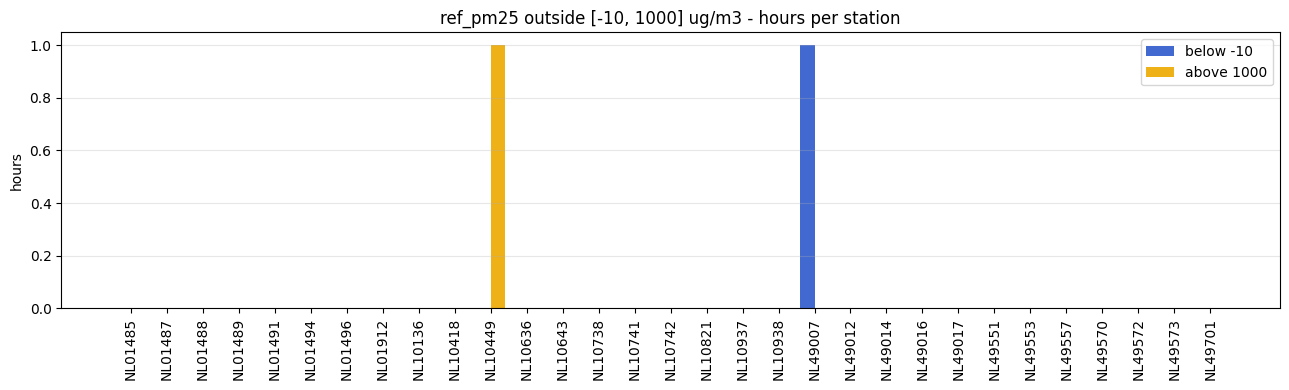

total below -10: 1 | total above 1000: 1


,below,above
station,,
NL10449,0,1
NL49007,1,0


In [12]:
REF_MIN = -10.0    # ug/m3
REF_MAX = 1000.0   # ug/m3

rows = []
for name in stations:
    s = stations[name]["ref_pm25"]
    rows.append({
        "station": name.split("_")[0],
        "below": int((s < REF_MIN).sum()),
        "above": int((s > REF_MAX).sum()),
    })
ref_outliers = pd.DataFrame(rows).set_index("station")

fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(len(ref_outliers))
ax.bar(x - 0.2, ref_outliers["below"], width=0.4, color="#4269d0", label="below %g" % REF_MIN)
ax.bar(x + 0.2, ref_outliers["above"], width=0.4, color="#efb118", label="above %g" % REF_MAX)
ax.set_xticks(x)
ax.set_xticklabels(ref_outliers.index, rotation=90)
ax.set_ylabel("hours")
ax.set_title("ref_pm25 outside [%g, %g] ug/m3 - hours per station" % (REF_MIN, REF_MAX))
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("total below %g: %d | total above %g: %d"
      % (REF_MIN, ref_outliers["below"].sum(), REF_MAX, ref_outliers["above"].sum()))
ref_outliers[(ref_outliers["below"] > 0) | (ref_outliers["above"] > 0)]

In [ ]:
# mark the out of range hours as missing so the KNN imputation fills them
total_marked = 0
for name in stations:
    df = stations[name]
    bad = (df["ref_pm25"] < REF_MIN) | (df["ref_pm25"] > REF_MAX)
    n_bad = int(bad.sum())
    if n_bad > 0:
        df.loc[bad, "ref_pm25"] = np.nan
        total_marked += n_bad
        print(name, "->", n_bad, "hours marked as missing")

print()
print("total hours marked as missing:", total_marked)

NL10449_PM2.5_lucht -> 1 hours marked as missing
NL49007_PM2.5_lucht -> 1 hours marked as missing

total hours marked as missing: 2


## 4. Multivariate KNN imputation (k=5)

Done per station. For each station:

1. Build a matrix of all numeric columns except `ID_COLS` (the ERA5 / EAC4 variables plus the two PM2.5 columns).
2. Standardize every column (`(x - mean) / std`) so the distance is not dominated by columns with big units.
3. Run `KNNImputer(n_neighbors=5)`: for an hour with a missing value it finds the 5 most similar hours (NaN-aware euclidean distance over the scaled columns) and fills the gap with the mean of those 5 neighbors
4. Un-scale, and write **only** `ref_pm25` and `lcs_median_pm25` back into the dataframe
5. Save the result to `data_imputed/<station>/<station>.csv`.

Columns that are constant or completely empty in a station are dropped from the matrix

In [ ]:
stations_imputed = {}

for name in stations:
    t0 = time.time()
    df = stations[name].copy()

    # build the matrix
    matrix_cols = []
    for col in df.columns:
        if col not in ID_COLS:
            matrix_cols.append(col)

    X = df[matrix_cols]
    means = X.mean()
    stds = X.std()

    # drop constant or completely empty columns
    keep_cols = []
    dropped = []
    for col in matrix_cols:
        if stds[col] > 0:
            keep_cols.append(col)
        else:
            dropped.append(col)
    if len(dropped) > 0:
        print(name, "-> dropped from KNN matrix:", dropped)

    # standardize
    X = X[keep_cols]
    X_scaled = (X - means[keep_cols]) / stds[keep_cols]

    # impute
    imputer = KNNImputer(n_neighbors=K)
    result = imputer.fit_transform(X_scaled)

    # 4. un-scale and write the two target columns back
    X_imputed = pd.DataFrame(result, columns=keep_cols, index=X.index)
    X_imputed = X_imputed * stds[keep_cols] + means[keep_cols]

    for col in TARGET_COLS:
        if col in keep_cols:
            df[col] = X_imputed[col]

    stations_imputed[name] = df

    # save, same folder layout as the original data
    out_folder = os.path.join(OUT_DIR, name)
    os.makedirs(out_folder, exist_ok=True)
    df.to_csv(os.path.join(out_folder, name + ".csv"), index=False)

    print(name, "-> done in", round(time.time() - t0, 1), "seconds")

print()
print("all stations imputed")

NL01485_PM2.5_lucht -> done in 23.3 seconds
NL01487_PM2.5_lucht -> done in 4.7 seconds
NL01488_PM2.5_lucht -> done in 4.1 seconds
NL01489_PM2.5_lucht -> done in 23.9 seconds
NL01491_PM2.5_lucht -> done in 24.0 seconds
NL01494_PM2.5_lucht -> done in 9.9 seconds
NL01496_PM2.5_lucht -> done in 24.3 seconds
NL01912_PM2.5_lucht -> done in 9.5 seconds
NL10136_PM2.5_lucht -> done in 38.3 seconds
NL10418_PM2.5_lucht -> done in 4.9 seconds
NL10449_PM2.5_lucht -> done in 11.7 seconds
NL10636_PM2.5_lucht -> done in 4.9 seconds
NL10643_PM2.5_lucht -> done in 4.6 seconds
NL10738_PM2.5_lucht -> done in 33.2 seconds
NL10741_PM2.5_lucht -> done in 5.2 seconds
NL10742_PM2.5_lucht -> done in 4.4 seconds
NL10821_PM2.5_lucht -> done in 34.3 seconds
NL10937_PM2.5_lucht -> done in 4.6 seconds
NL10938_PM2.5_lucht -> done in 6.3 seconds
NL49007_PM2.5_lucht -> done in 4.9 seconds
NL49012_PM2.5_lucht -> done in 3.6 seconds
NL49014_PM2.5_lucht -> done in 6.1 seconds
NL49016_PM2.5_lucht -> done in 9.1 seconds
NL4

## 5. Scores after imputation

Same % filled score for `ref_pm25` and `lcs_median_pm25`, before vs after. The table is also saved to `data_imputed/imputation_report.csv`.

In [ ]:
rows = []
total_hours = 0
ref_before_total = 0
ref_after_total = 0
lcs_before_total = 0
lcs_after_total = 0

for name in stations:
    before = stations[name]
    after = stations_imputed[name]

    n = len(before)
    ref_b = before["ref_pm25"].notna().sum()
    ref_a = after["ref_pm25"].notna().sum()
    lcs_b = before["lcs_median_pm25"].notna().sum()
    lcs_a = after["lcs_median_pm25"].notna().sum()

    total_hours += n
    ref_before_total += ref_b
    ref_after_total += ref_a
    lcs_before_total += lcs_b
    lcs_after_total += lcs_a

    rows.append({
        "station": name,
        "ref_before_%": round(ref_b / n * 100, 1),
        "ref_after_%": round(ref_a / n * 100, 1),
        "lcs_before_%": round(lcs_b / n * 100, 1),
        "lcs_after_%": round(lcs_a / n * 100, 1),
    })

rows.append({
    "station": "ALL STATIONS",
    "ref_before_%": round(ref_before_total / total_hours * 100, 1),
    "ref_after_%": round(ref_after_total / total_hours * 100, 1),
    "lcs_before_%": round(lcs_before_total / total_hours * 100, 1),
    "lcs_after_%": round(lcs_after_total / total_hours * 100, 1),
})

report = pd.DataFrame(rows)
report.to_csv(os.path.join(OUT_DIR, "imputation_report.csv"), index=False)
report

,station,ref_before_%,ref_after_%,lcs_before_%,lcs_after_%
0,NL01485_PM2.5_lucht,99.3,100.0,80.6,100.0
1,NL01487_PM2.5_lucht,98.4,100.0,97.6,100.0
2,NL01488_PM2.5_lucht,99.3,100.0,97.6,100.0
3,NL01489_PM2.5_lucht,99.3,100.0,72.8,100.0
4,NL01491_PM2.5_lucht,99.5,100.0,82.9,100.0
5,NL01494_PM2.5_lucht,99.6,100.0,91.2,100.0
6,NL01496_PM2.5_lucht,99.4,100.0,73.2,100.0
7,NL01912_PM2.5_lucht,98.4,100.0,92.4,100.0
8,NL10136_PM2.5_lucht,93.8,100.0,68.2,100.0
9,NL10418_PM2.5_lucht,97.9,100.0,97.8,100.0


In [ ]:
# the imputed values should stay within range
rows = []
for col in TARGET_COLS:
    before_parts = []
    after_parts = []
    for name in stations:
        before_parts.append(stations[name][col])
        after_parts.append(stations_imputed[name][col])
    s_before = pd.concat(before_parts)
    s_after = pd.concat(after_parts)

    rows.append({
        "column": col,
        "min_before": round(s_before.min(), 2),
        "max_before": round(s_before.max(), 2),
        "min_after": round(s_after.min(), 2),
        "max_after": round(s_after.max(), 2),
    })

pd.DataFrame(rows)

,column,min_before,max_before,min_after,max_after
0,ref_pm25,-5.30,673.34,-5.30,673.34
1,lcs_median_pm25,-6.35,49.40,-6.35,49.40
